In [1]:
devtools::load_all("/home/tangyh/script/Modsite")

ℹ Loading modsite
Warning message:
“package ‘testthat’ was built under R version 4.4.3”


In [2]:
base_dir <- "/data_new/RNA_modi/puseq/BN0045"

files <- list.files(
  path = base_dir,
  pattern = "^genome\\.sites\\.tsv$",
  recursive = TRUE,
  full.names = TRUE
)

files <- normalizePath(files, winslash = "/", mustWork = FALSE)

sample_files <- files[!grepl("NC", files)]
conditions <- c("ctrl", "ctrl", "ctrl", "ctrl", "ctrl", "ctrl","ctrl", "ctrl", "ctrl", "ctrl", 
                "ctrl", "ctrl","ctrl", "ctrl", "ctrl", "ctrl", "ctrl", "ctrl","ctrl", "ctrl", 
                "case", "case", "case","case", "case", "case","case", "case", "case", "case",
                "case", "case", "case","case", "case", "case","case", "case", "case")


In [ ]:
m <- new_merger(
  sample_files        = sample_files,
  condition           = conditions,
  modification_method = "PUMseq",
  min_modification_rate = 0.05,
  min_depth           = 10L,
  group_missing_threshold = 0.2,
  group_filter_strategy = "all"
)
merged_df <- merge_samples(m)

In [ ]:
filter_samples(m, max_missing_rate = 0.8)


In [ ]:
sample_names <- unname(m$sample_names)
sample_names 

In [36]:
ds <- new_diff_sites(
  annotated_df = m$merged_data,
  group1_samples = sample_names[1:19],
  group2_samples = sample_names[20:37],
  group1_name = "A",
  group2_name = "B",
  test_method = "wilcox-test",
  min_abs_log2fc = 9,
  p_value_threshold = 0.05,
  min_samples_per_group = 2
)
res <- run_diff_sites(ds)
sig_res <- res[res$significant, ]
#save_diff_results(sig_res, "diff_sites_sig.tsv", include_all = TRUE)

In [39]:
write.csv(res,"/home/tangyh/script/Modsite/modsite.Rcheck/res.csv")

In [51]:
sample_ids <- unname(m$sample_names)
n <- length(sample_ids)
set.seed(1)
m$sample_meta <- data.frame(
  sample_id = sample_ids,
  group = factor(
    sample(rep(c("ctrl", "trt"), length.out = n)),
    levels = c("ctrl", "trt")
  ),
  sex = factor(
    sample(rep(c("M", "F"), length.out = n))
  ),
  batch = factor(
    sample(rep(paste0("batch", 1:4), length.out = n))
  ),
  stringsAsFactors = FALSE
)
cat("group table:\n")
print(table(m$sample_meta$group))
cat("sex table:\n")
print(table(m$sample_meta$sex))
cat("batch table:\n")
print(table(m$sample_meta$batch))
phi_vars <- intersect(c("motif", "strand", "genomic_region"), colnames(m$merged_data))
cat("usable phi_vars:", paste(phi_vars, collapse = ", "), "\n")

group table:

ctrl  trt 
  20   19 
sex table:

 F  M 
19 20 
batch table:

batch1 batch2 batch3 batch4 
    10     10     10      9 
usable phi_vars: motif, strand 


In [52]:
m$sample_meta

sample_id,group,sex,batch
<chr>,<fct>,<fct>,<fct>
DY-11-24,trt,M,batch1
DY-11-25,ctrl,F,batch1
DY-11-26,trt,M,batch3
DY-13-PU-21,ctrl,F,batch1
DY-13-PU-23,trt,F,batch1
DY-13-PU-27,trt,F,batch3
DY-13-PU-28,ctrl,F,batch3
DY-13-PU-29,ctrl,F,batch2
DY-13-PU-5,trt,F,batch2


In [53]:
glmm_out_basic <- run_glmm(
  merger = m,
  fixed = c("group", "batch"),
  primary_term = "group",
  min_depth_site = 5L,
  min_samples_per_site = 6L,
  n_cores = 1L,
  on_error = "warn",
  phi = FALSE
)
ptb_basic <- glmm_out_basic$primary_term_backfill
ptb_basic <- ptb_basic[order(ptb_basic$group_adj_p.value), ]
print(head(ptb_basic, 10))
cat("Sites fitted OK:", sum(ptb_basic$fit_ok, na.rm = TRUE), "/", nrow(ptb_basic), "\n")
print(table(ptb_basic$fit_ok, useNA = "ifany"))
print(table(ptb_basic$or_extreme, useNA = "ifany"))

[run_glmm] Removed 2528 observation(s) with NA k (missing rate or depth).

Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; false convergence (8). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; false convergence (8). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; false convergence (8). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model 

# A tibble: 10 × 14
   site_id          chrom      pos ref   strand motif group_est_logodds group_or
   <chr>            <chr>    <int> <chr> <chr>  <chr>             <dbl>    <dbl>
 1 19_53874774_T_-  19      5.39e7 T     -      TTTTT           -0.0803   0.923 
 2 16_3307747_T_+   16      3.31e6 T     +      GGTCT           -2.62     0.0726
 3 18_12651665_T_-  18      1.27e7 T     -      ACTCC           -0.883    0.414 
 4 5_17275946_T_-   5       1.73e7 T     -      CCTCT           -1.25     0.285 
 5 7_139905083_T_-  7       1.40e8 T     -      CTTTC            0.458    1.58  
 6 17_16441272_T_-  17      1.64e7 T     -      TGTAG            0.365    1.44  
 7 20_49278967_T_-  20      4.93e7 T     -      TTTTC           -0.835    0.434 
 8 14_100239120_T_- 14      1.00e8 T     -      TCTCC           -1.31     0.269 
 9 17_39201278_T_-  17      3.92e7 T     -      GTTAG            0.460    1.58  
10 19_7385877_T_-   19      7.39e6 T     -      CCTCC           -1.18     0.309 
# ℹ 6 mo

In [54]:
glmm_out_basic

site_id,chrom,pos,ref,strand,motif,group_est_logodds,group_or,group_p.value,group_adj_p.value,fit_ok,error_msg,primary_match_error,or_extreme
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,<chr>,<lgl>
19_53874774_T_-,19,53874774,T,-,TTTTT,-0.08027355,0.92286386,4.776043e-12,3.897251e-09,TRUE,NA,NA,FALSE
16_3307747_T_+,16,3307747,T,+,GGTCT,-2.62331970,0.07256158,3.674787e-03,6.319809e-01,TRUE,NA,NA,FALSE
18_12651665_T_-,18,12651665,T,-,ACTCC,-0.88269116,0.41366817,2.317850e-03,6.319809e-01,TRUE,NA,NA,FALSE
5_17275946_T_-,5,17275946,T,-,CCTCT,-1.25383274,0.28540880,3.687330e-03,6.319809e-01,TRUE,NA,NA,FALSE
7_139905083_T_-,7,139905083,T,-,CTTTC,0.45776585,1.58053888,3.872432e-03,6.319809e-01,TRUE,NA,NA,FALSE
17_16441272_T_-,17,16441272,T,-,TGTAG,0.36460794,1.43994936,5.463754e-03,7.430705e-01,TRUE,NA,NA,FALSE
20_49278967_T_-,20,49278967,T,-,TTTTC,-0.83470979,0.43400042,6.767755e-03,7.889268e-01,TRUE,NA,NA,FALSE
14_100239120_T_-,14,100239120,T,-,TCTCC,-1.31181806,0.26932995,1.422562e-02,8.023268e-01,TRUE,NA,NA,FALSE
17_39201278_T_-,17,39201278,T,-,GTTAG,0.45958067,1.58340987,8.154027e-03,8.023268e-01,TRUE,NA,NA,FALSE


In [55]:
stopifnot(length(phi_vars) > 0)
estimate_phi_trend(
  merger = m,
  phi_vars = c("motif", "strand"),
  min_depth_site = 5L,
  min_samples_per_site = 6L,
  verbose = TRUE
)
str(m$phi_trend)
glmm_out_phi <- run_glmm(
  merger = m,
  fixed = c("group", "batch"),
  primary_term = "group",
  min_depth_site = 5L,
  min_samples_per_site = 6L,
  n_cores = 1L,
  on_error = "warn",
  phi = TRUE
)
ptb_phi <- glmm_out_phi$primary_term_backfill
ptb_phi <- ptb_phi[order(ptb_phi$group_adj_p.value), ]
print(head(ptb_phi, 10))
cat("Sites fitted OK with phi:", sum(ptb_phi$fit_ok, na.rm = TRUE), "/", nrow(ptb_phi), "\n")
print(table(ptb_phi$fit_ok, useNA = "ifany"))
print(table(ptb_phi$or_extreme, useNA = "ifany"))

[estimate_phi_trend] Running intercept-only free fits for 819 sites...

Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; false convergence (8). See vignette('troubleshooting'), help('diagnose')”
Warning message in sqrt(as.numeric(vc[dkey, dkey])):
“NaNs produced”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; false convergence (8). See vignette('troubleshooting'), help('diagnose')”
Warning message in sqrt(as.numeric(vc[dkey, dkey])):
“NaNs produced”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; false convergen

List of 10
 $ phi_df       :'data.frame':	819 obs. of  8 variables:
  ..$ site_id    : chr [1:819] "1_632693_T_-" "1_632695_T_-" "1_632696_T_-" "1_9728616_T_-" ...
  ..$ theta_hat  : num [1:819] -2.05 -2.49 -3.46 2.4 203.34 ...
  ..$ se_theta   : num [1:819] 0.495 0.531 0.722 0.507 NaN ...
  ..$ theta_ok   : logi [1:819] TRUE TRUE TRUE TRUE FALSE TRUE ...
  ..$ mu_trend   : num [1:819] -2.05 -2.34 -3.46 1.89 5.38 ...
  ..$ theta_final: num [1:819] -2.05 -2.34 -3.46 1.89 5.38 ...
  ..$ phi_final  : num [1:819] 0.1281 0.0961 0.0315 6.5915 217.0857 ...
  ..$ trend_type : chr [1:819] "linear" "linear" "linear" "linear" ...
 $ trend_formula:Class 'formula'  language theta_hat ~ motif + strand
  .. ..- attr(*, ".Environment")=<environment: 0x55b12054d7a0> 
 $ trend_type   : chr "linear"
 $ phi_vars     : chr [1:2] "motif" "strand"
 $ n_sites_total: int 819
 $ n_sites_fit  : int 814
 $ n_sites_trend: int 814
 $ fit_ok       : logi TRUE
 $ warning_msg  : NULL
 $ trend_model  :List of 14
  ..$ 

[run_glmm] Removed 2528 observation(s) with NA k (missing rate or depth).

[run_glmm] Trend phi (linear): 819 site(s) use trend value, 0 site(s) fall back to free estimation.

[run_glmm] Progress: 100 / 819 sites

[run_glmm] Progress: 200 / 819 sites

[run_glmm] Progress: 300 / 819 sites

[run_glmm] Progress: 400 / 819 sites

[run_glmm] Progress: 500 / 819 sites

Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; false convergence (8). See vignette('troubleshooting'), help('diagnose')”
[run_glmm] Progress: 600 / 819 sites

Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')”
[run_glmm] Progress: 700 / 819 sites

Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc

# A tibble: 10 × 14
   site_id          chrom      pos ref   strand motif group_est_logodds group_or
   <chr>            <chr>    <int> <chr> <chr>  <chr>             <dbl>    <dbl>
 1 MT_10873_T_-     MT      1.09e4 T     -      CCTCT             -2.77   0.0628
 2 MT_16093_T_-     MT      1.61e4 T     -      ATTTC             -4.41   0.0121
 3 19_24001288_T_+  19      2.40e7 T     +      TCTCC              1.92   6.84  
 4 1_32964501_T_+   1       3.30e7 T     +      GCTGC             -3.20   0.0407
 5 16_3307747_T_+   16      3.31e6 T     +      GGTCT             -3.48   0.0308
 6 14_100239120_T_- 14      1.00e8 T     -      TCTCC             -1.48   0.228 
 7 17_16441286_T_-  17      1.64e7 T     -      TATGG             -1.97   0.140 
 8 19_24001300_T_+  19      2.40e7 T     +      CCTTC              1.70   5.46  
 9 MT_681_T_-       MT      6.81e2 T     -      CTTAG             -2.42   0.0890
10 8_23571816_T_-   8       2.36e7 T     -      TTTCT              1.83   6.25  
# ℹ 6 mo

In [56]:
glmm_out_phi$primary_term_backfill

site_id,chrom,pos,ref,strand,motif,group_est_logodds,group_or,group_p.value,group_adj_p.value,fit_ok,error_msg,primary_match_error,or_extreme
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,<chr>,<lgl>
1_632693_T_-,1,632693,T,-,GATAT,-1.502522184,0.2225681,1.138150e-01,0.999984385,TRUE,NA,NA,FALSE
1_632695_T_-,1,632695,T,-,TATTA,0.914902635,2.4965322,3.046327e-01,0.999984385,TRUE,NA,NA,FALSE
1_632696_T_-,1,632696,T,-,ATTAG,1.419657815,4.1357050,1.408312e-01,0.999984385,TRUE,NA,NA,FALSE
1_9728616_T_-,1,9728616,T,-,GTTCC,0.370043301,1.4477973,4.660150e-01,0.999984385,TRUE,NA,NA,FALSE
1_10316929_T_+,1,10316929,T,+,GATGG,0.629400220,1.8764848,5.386145e-01,0.999984385,TRUE,NA,NA,FALSE
1_10316937_T_+,1,10316937,T,+,CTTGC,0.019683275,1.0198783,9.584909e-01,0.999984385,TRUE,NA,NA,FALSE
1_10316975_T_+,1,10316975,T,+,CCTGA,0.143949609,1.1548259,8.364001e-01,0.999984385,TRUE,NA,NA,FALSE
1_11908162_T_-,1,11908162,T,-,GTTTC,-0.012574078,0.9875046,9.404356e-01,0.999984385,TRUE,NA,NA,FALSE
1_11908173_T_-,1,11908173,T,-,AATCG,0.558094560,1.7473399,2.704910e-01,0.999984385,TRUE,NA,NA,FALSE


In [57]:
write.csv(glmm_out_phi$primary_term_backfill, "/home/tangyh/script/Modsite/modsite.Rcheck/glm.csv")

In [58]:
merged_df

chrom,pos,ref,strand,motif,DY-11-24,depth_DY-11-24,DY-11-25,depth_DY-11-25,DY-11-26,⋯,S2-ZJ18,depth_S2-ZJ18,S2-ZJ20,depth_S2-ZJ20,S2-ZJ22,depth_S2-ZJ22,S2-ZJ30,depth_S2-ZJ30,S2-ZJ6,depth_S2-ZJ6
<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,⋯,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>
1,632693,T,-,GATAT,0.00000000,175,1.0000000,263,0.00000000,⋯,0.00000000,84,1.00000000,391,0.00000000,29,0.33333333,854,0.0000000,12
1,632695,T,-,TATTA,0.00000000,175,0.0000000,263,0.00000000,⋯,0.00000000,81,0.50000000,391,0.00000000,29,0.66666667,854,0.0000000,12
1,632696,T,-,ATTAG,0.00000000,175,0.0000000,264,0.00000000,⋯,0.00000000,82,0.00000000,391,0.00000000,29,1.00000000,854,0.0000000,12
1,9728616,T,-,GTTCC,0.11594203,69,0.0000000,21,0.06896552,⋯,0.10000000,10,0.07200000,125,0.00000000,10,0.00000000,12,NA,0
1,10316929,T,+,GATGG,1.00000000,129,NA,0,1.00000000,⋯,1.00000000,36,0.99682540,319,1.00000000,93,1.00000000,252,0.9892473,98
1,10316937,T,+,CTTGC,0.95070423,149,NA,0,0.93055556,⋯,0.97727273,44,0.98005698,351,0.98019802,105,0.97909408,288,0.9819820,112
1,10316975,T,+,CCTGA,0.98734177,87,NA,0,1.00000000,⋯,1.00000000,24,1.00000000,199,1.00000000,67,0.99456522,185,1.0000000,60
1,11908162,T,-,GTTTC,0.24909747,277,0.1941748,103,0.25196850,⋯,0.22916667,96,0.21212121,331,0.48000000,75,0.41319444,289,0.5000000,28
1,11908173,T,-,AATCG,0.44848485,330,0.7500000,108,0.52112676,⋯,0.00000000,109,0.59296482,401,0.00000000,86,0.00000000,351,0.5428571,35


In [ ]:
library(modsite)
# 1. 读入 GLMM 结果
glmm_df <- read.csv(
  "/home/tangyh/script/Modsite/modsite.Rcheck/glm.csv",
  stringsAsFactors = FALSE
)
# 可选：确保常用列类型正确
glmm_df$chrom <- as.character(glmm_df$chrom)
if ("strand" %in% names(glmm_df)) {
  glmm_df$strand <- as.character(glmm_df$strand)
}
# 看一下列名是否符合预期
print(colnames(glmm_df))
head(glmm_df)
# 2. 构建 metagene analyzer
# ann 需要是你已经准备好的 GenomicAnnotator 对象
# 例如：
# ann <- new_genomic_annotator(gtf_file = "/path/to/annotation.gtf")
mg <- new_metagene_analyzer(
  annotator = ann,
  sites_df = glmm_df,
  n_bins = 100
)
# --------------------------------------------------
# 示例 A: 按 motif 分组
# --------------------------------------------------
mg_motif <- calc_grouped_metagene_profile(
  mg,
  group_by = "motif",
  stat = "density",
  filter = ~ fit_ok & !or_extreme,
  smooth = TRUE,
  span = 0.3
)
p_motif <- plot_metagene_groups(
  mg_motif,
  title = "Grouped Metagene by Motif",
  output_file = "/home/tangyh/script/Modsite/modsite.Rcheck/metagene_by_motif.png"
)
print(p_motif)
# 查看分组后的 profile 数据
head(mg_motif$grouped_profile_data)
# --------------------------------------------------
# 示例 B: 按 adj p-value 二分
# 默认 <= 0.05 和 > 0.05
# --------------------------------------------------
mg_padj <- calc_grouped_metagene_profile(
  mg,
  group_by = "group_adj_p.value",
  group_cutoff = 0.05,
  stat = "density",
  filter = ~ fit_ok & !or_extreme,
  smooth = TRUE,
  span = 0.3
)
p_padj <- plot_metagene_groups(
  mg_padj,
  title = "Grouped Metagene by Adjusted P-value",
  output_file = "/home/tangyh/script/Modsite/modsite.Rcheck/metagene_by_padj.png"
)
print(p_padj)
table(unique(mg_padj$grouped_profile_data[, c("group", "n_sites")]))
# --------------------------------------------------
# 示例 C: 按 adj p-value 二分，并用 -log10(adj p) 加权
# 更强调显著性强的位点
# --------------------------------------------------
mg_padj_weighted <- calc_grouped_metagene_profile(
  mg,
  group_by = "group_adj_p.value",
  group_cutoff = 0.05,
  stat = "density",
  weight_by = "minus_log10_padj",
  padj_col = "group_adj_p.value",
  filter = ~ fit_ok & !or_extreme,
  smooth = TRUE,
  span = 0.3
)
p_padj_weighted <- plot_metagene_groups(
  mg_padj_weighted,
  title = "Weighted Metagene by Adjusted P-value",
  output_file = "/home/tangyh/script/Modsite/modsite.Rcheck/metagene_by_padj_weighted.png"
)
print(p_padj_weighted)
# --------------------------------------------------
# 示例 D: 自定义数值分组
# 比如把 adj p 分成三组
# --------------------------------------------------
mg_padj_3 <- calc_grouped_metagene_profile(
  mg,
  group_by = "group_adj_p.value",
  group_breaks = c(-Inf, 0.01, 0.05, Inf),
  group_labels = c("<=0.01", "0.01-0.05", ">0.05"),
  stat = "density",
  filter = ~ fit_ok & !or_extreme,
  smooth = TRUE,
  span = 0.3
)
p_padj_3 <- plot_metagene_groups(
  mg_padj_3,
  title = "Grouped Metagene by Adjusted P-value (3 groups)",
  output_file = "/home/tangyh/script/Modsite/modsite.Rcheck/metagene_by_padj_3groups.png"
)
print(p_padj_3)

ℹ Loading modsite
Loading GTF and building TxDb: Homo_sapiens.GRCh38.113.gtf

Import genomic features from the file as a GRanges object ... 
OK

Prepare the 'metadata' data frame ... 
OK

Make the TxDb object ... 
Warning message in .get_cds_IDX(mcols0$type, mcols0$phase):
“The "phase" metadata column contains non-NA values for features of type
  stop_codon. This information was ignored.”
OK

Importing GTF for gene metadata ...

Pre-extracting transcript features ...

Building transcript-to-gene mapping ...

'select()' returned 1:1 mapping between keys and columns

Annotator ready in 199.6 s.

Initialising MetageneAnalyzer: 819 sites, 100 bins, strategy = median

Mapping sites to transcript coordinates...



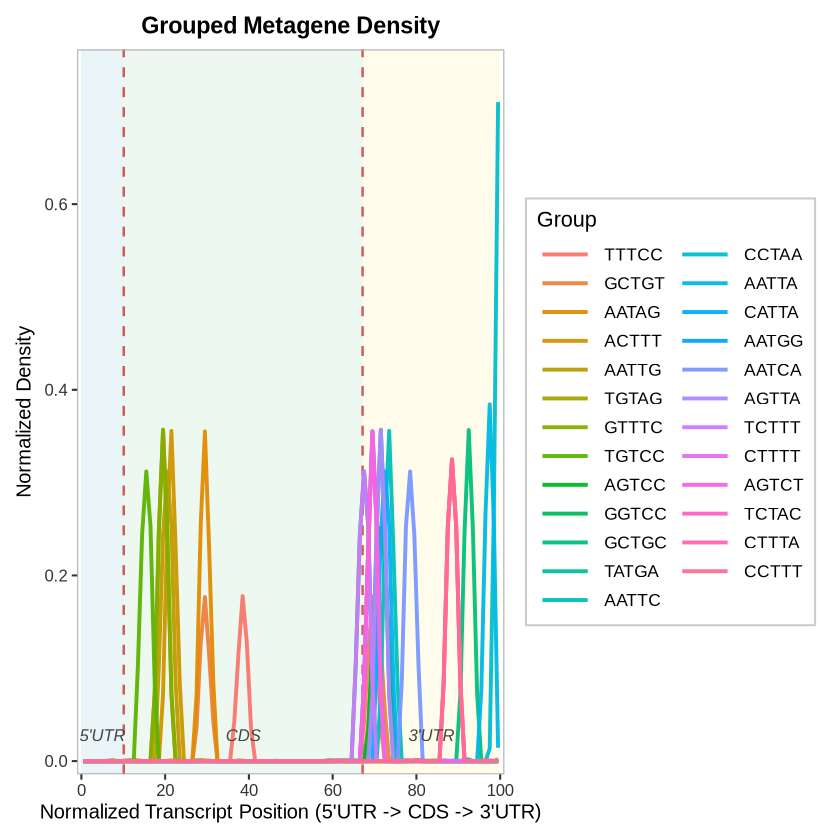

In [4]:
devtools::load_all("/home/tangyh/script/Modsite")
annotator <- new_genomic_annotator(
  gtf_file = "/home/tangyh/reference/Homo_sapiens.GRCh38.113.gtf"
)
glmm_df <- read.csv(
  "/home/tangyh/script/Modsite/modsite.Rcheck/glm.csv",
  stringsAsFactors = FALSE
)
glmm_df$chrom <- as.character(glmm_df$chrom)
if ("strand" %in% names(glmm_df)) {
  glmm_df$strand <- as.character(glmm_df$strand)
}
mg <- new_metagene_analyzer(
  annotator = annotator,
  sites_df = glmm_df,
  n_bins = 100
)
mg <- calc_grouped_metagene_profile(
  mg,
  group_by = "motif",
  stat = "density",
  filter = ~ fit_ok & !or_extreme
)
plot_metagene_groups(mg)

In [ ]:
p <- plot_metagene_groups(
  mg,
  title = "Grouped Metagene Density",
  output_file = "/home/tangyh/script/Modsite/modsite.Rcheck/metagene_motif_wide.png",
  width = 16,
  height = 6
)